In [20]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import pandas as pd

df = pd.read_csv("dataset_cleaned.csv")
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0.0,4.0,6.0,0.0,13.0,5.0,1
1,9.0,1.0,0.0,0.0,1.0,0.0,3.0,0
2,9.0,1.0,1.0,2.0,1.0,5.0,2.0,0
3,0.0,0.0,6.0,7.0,0.0,14.0,8.0,1
4,3.0,0.0,9.0,4.0,0.0,8.0,5.0,1


Our primary objective is to predict the Personality class. Before training, we must analyze the distribution of this target variable to ensure there is no severe class imbalance, which could lead to biased model predictions.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


print(" Personality Class Counts")
print(df['Personality'].value_counts())

# Calculate the percentage
print("\nPersonality Class Percentages")
print(df['Personality'].value_counts(normalize=True) * 100)

 Personality Class Counts
Personality
1    1491
0    1409
Name: count, dtype: int64

Personality Class Percentages
Personality
1    51.413793
0    48.586207
Name: proportion, dtype: float64


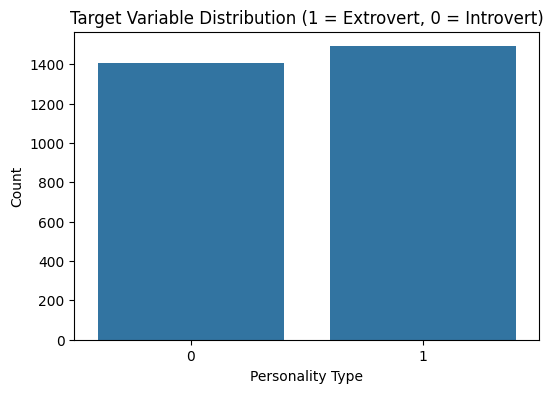

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Personality')
plt.title('Target Variable Distribution (1 = Extrovert, 0 = Introvert)')
plt.xlabel('Personality Type')
plt.ylabel('Count')
plt.show()

As above, we can conclude that our target variable col is balanced and we can move without any hindrance

NEXT: Analyzing Continuous Features (Finding the Outliers)

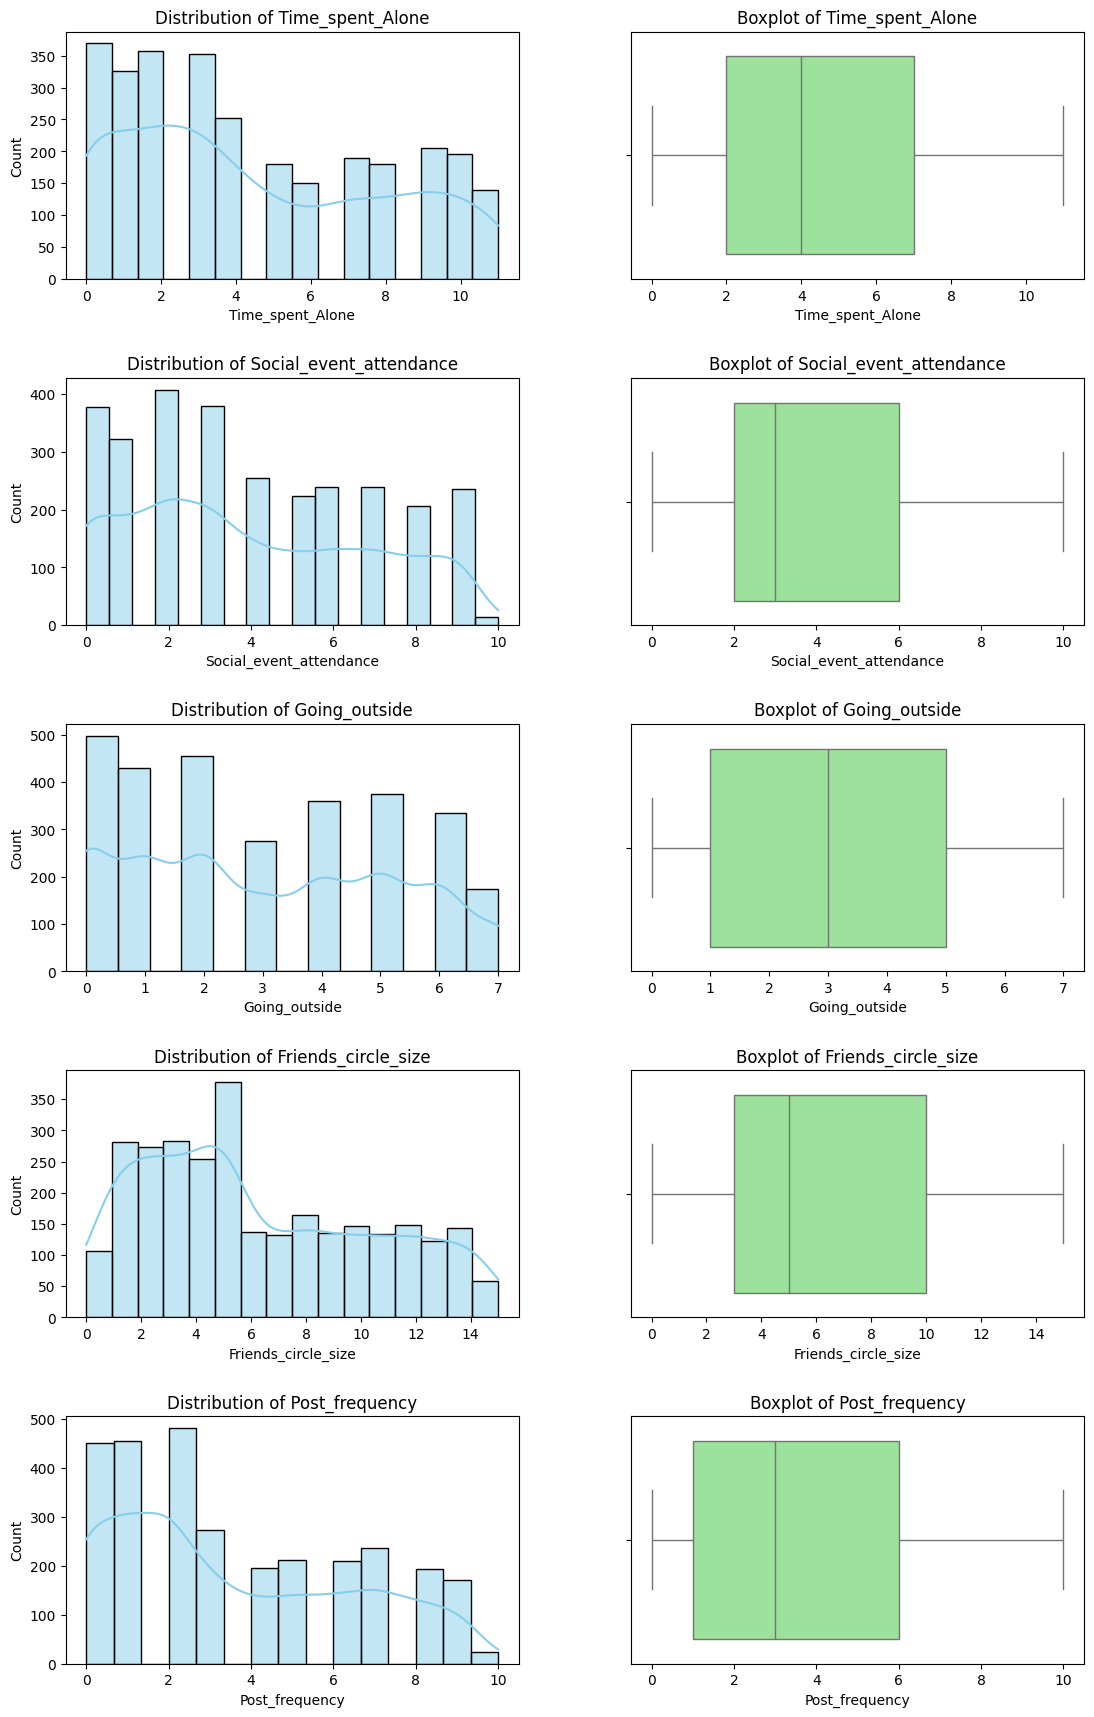

In [27]:
# List of our numerical columns
num_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']

fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, 18))
fig.tight_layout(pad=5.0)

for i, col in enumerate(num_cols):
   
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # Right Column: Boxplot (Outlier Detection)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.show()

conclusion: Outlier Absence ===> None of the continuous features exhibit extreme outliers beyond the standard IQR whiskers. The data is bounded logically meaning outlier treatment is unnecessary for this dataset.

NEXT: Categorical Feature Distribution

/tmp/ipykernel_14314/110770047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
/tmp/ipykernel_14314/110770047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')


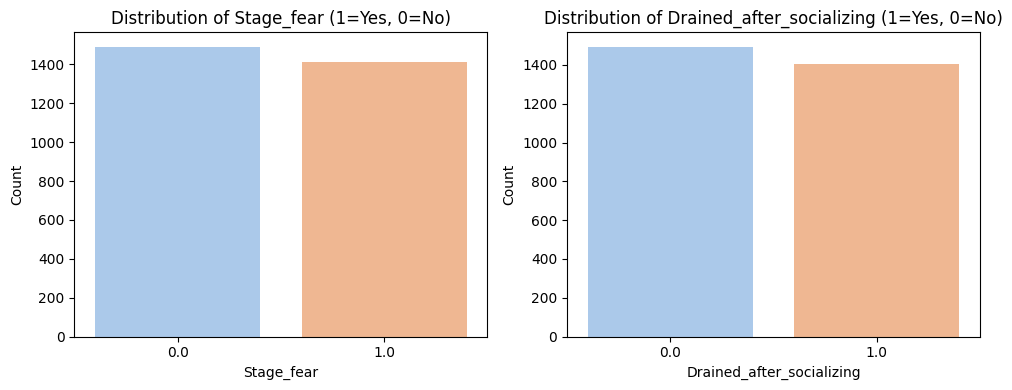

In [28]:

binary_cols = ['Stage_fear', 'Drained_after_socializing']


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(binary_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Distribution of {col} (1=Yes, 0=No)')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [29]:
print("--- Categorical Feature Percentages ---")
for col in binary_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True) * 100)

--- Categorical Feature Percentages ---

Stage_fear:
Stage_fear
0.0    51.37931
1.0    48.62069
Name: proportion, dtype: float64

Drained_after_socializing:
Drained_after_socializing
0.0    51.482759
1.0    48.517241
Name: proportion, dtype: float64


no single class heavily dominates the distribution, both features are validated as healthy, 
informative predictors